In [1]:
import cv2
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ultralytics
from ultralytics import YOLO
ultralytics.checks()

Ultralytics YOLOv8.2.2  Python-3.8.3 torch-2.2.2+cpu CPU (AMD Ryzen 5 PRO 5650U with Radeon Graphics)
Setup complete  (12 CPUs, 15.3 GB RAM, 231.3/476.2 GB disk)


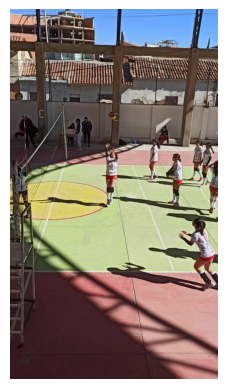

In [3]:
#path0='/content/46_051..jpg'
path0= 'C:\\MI-CARRERA\\Semestre7\\SIS330\\imagenes\\buenos\\1\\VID_20240602_101620_000001.jpg'
img=plt.imread(path0)
plt.imshow(img)#, cv2.COLOR_BGR2RGB)
plt.axis('off')
plt.show()

In [5]:
#path0= 'C:\\MI-CARRERA\\Semestre7\\SIS330\\PROYECTO\\prueba\\buenos\\50\\50_01_inicio..jpg'
#image = cv2.imread(path0)
#target_size = (640, 640)
#resized_image = cv2.resize(image, target_size)
#cv2.imshow('Resized Image', resized_image)
#cv2.waitKey(0)
#cv2.destroyAllWindows()


In [6]:
path0= 'C:\\MI-CARRERA\\Semestre7\\SIS330\\imagenes\\buenos\\1\\VID_20240602_101620_000001.jpg'
model = YOLO('C:\MI-CARRERA\Semestre7\SIS330\PROYECTO\SIS330\yolov8x-pose.pt')  # load an official model
# Predict with the model
results = model.track(path0,show =False, imgsz=[640, 640] )

100%|██████████| 133M/133M [01:52<00:00, 1.23MB/s] 



image 1/1 C:\MI-CARRERA\Semestre7\SIS330\imagenes\buenos\1\VID_20240602_101620_000001.jpg: 640x384 8 persons, 1079.6ms
Speed: 8.6ms preprocess, 1079.6ms inference, 2478.1ms postprocess per image at shape (1, 3, 640, 384)


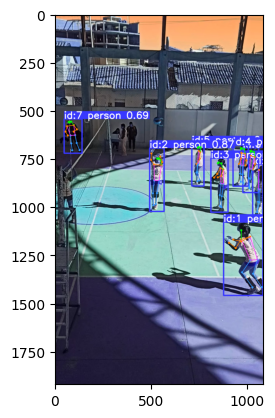

In [7]:
annotated_frame = results[0].plot()
plt.imshow(annotated_frame)#, cv2.COLOR_BGR2RGB)
plt.show()

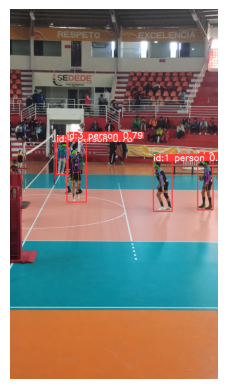

In [25]:
path0='C:\\MI-CARRERA\\Semestre7\\SIS330\\PROYECTO\\SIS330\\runs\\pose\\track2\\52_01_inicio..jpg'
img=plt.imread(path0)
plt.imshow(img)#, cv2.COLOR_BGR2RGB)
plt.axis('off')
plt.show()

In [8]:
print(len(results[0].boxes))

8


In [12]:
BOX=pd.DataFrame(columns=range(7))
for i in range(len(results)):
    arri = pd.DataFrame(results[0].boxes.data.cpu()).astype(float)  # Copiar a la CPU antes de convertir a NumPy
    arri['i']=i
    BOX=pd.concat([BOX,arri],axis=0)
BOX.columns=['x','y','x2','y2','id','confidence','class','']
display(BOX)

,x,y,x2,y2,id,confidence,class,
0,875.0,1079.0,1079.0,1460.0,1.0,0.902160,0.0,0.0
1,491.0,695.0,566.0,1024.0,2.0,0.870988,0.0,0.0
2,809.0,748.0,898.0,1028.0,3.0,0.847227,0.0,0.0
3,924.0,680.0,1004.0,893.0,4.0,0.815556,0.0,0.0
4,710.0,672.0,773.0,892.0,5.0,0.814618,0.0,0.0
5,975.0,694.0,1057.0,926.0,6.0,0.794786,0.0,0.0
6,47.0,544.0,140.0,722.0,7.0,0.691864,0.0,0.0
7,1026.0,779.0,1079.0,1065.0,8.0,0.684042,0.0,0.0


In [13]:
a=len(results[0].boxes)
print(a)
for i in range(a):
  if results[0].boxes.id[i] == 1:
    #for i in range(len(results)):
    points=results[i].keypoints[i].xyn.data.cpu().numpy()
    #print(points)
    ls=[]
    matriz_np = np.array(points)
    matriz_aplanada_np = matriz_np.flatten()
    valor=matriz_aplanada_np.tolist()
    #print(matriz_aplanada_np.tolist())
    ls.append(valor)
    #print(valor)
    print(ls)

8
[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8957114815711975, 0.5848522186279297, 0.0, 0.0, 0.8956534266471863, 0.6088556051254272, 0.9381600022315979, 0.6016300916671753, 0.869121789932251, 0.6325786113739014, 0.8958240747451782, 0.6150100827217102, 0.8369668126106262, 0.6184068918228149, 0.8567454218864441, 0.6095556020736694, 0.9390631914138794, 0.6655018329620361, 0.9735158085823059, 0.6640021204948425, 0.8999103903770447, 0.6983001828193665, 0.9523136615753174, 0.7020368576049805, 0.9490895867347717, 0.738835334777832, 0.9941675066947937, 0.7384175658226013]]


In [14]:
df = pd.DataFrame(ls)
print(df)
df.to_csv("bue"+".txt")

    0    1    2    3    4    5         6         7    8    9   ...        24  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.895711  0.584852  0.0  0.0  ...  0.973516   

         25       26      27        28        29       30        31        32  \
0  0.664002  0.89991  0.6983  0.952314  0.702037  0.94909  0.738835  0.994168   

         33  
0  0.738418  

[1 rows x 34 columns]


In [35]:
import os
import cv2
from ultralytics import YOLO

# Directorio principal que contiene subcarpetas con imágenes
directorio_principal = "C:\\MI-CARRERA\\Semestre7\\SIS330\\imagenes\\malos\\malo3"

# Directorio donde se guardarán los resultados
directorio_resultados = "C:\\MI-CARRERA\\Semestre7\\SIS330\\imagenes\\malos\\malo3"
resultados_carpeta_actual = []
# Load the YOLOv8 model
for carpeta in os.listdir(directorio_principal):
    print("entro",carpeta)
    carpeta_actual = os.path.join(directorio_principal, carpeta)
    if os.path.isdir(carpeta_actual):
        # Crear una nueva instancia del modelo YOLO para cada carpeta
        model = YOLO('C:\EV\PROYECTO\yolov8x-pose.pt')
        
        # Carpeta donde se guardarán los resultados para esta carpeta
        carpeta_resultados = os.path.join(directorio_resultados, carpeta+"resultados")
        os.makedirs(carpeta_resultados, exist_ok=True)
        
        # Procesar cada imagen en la carpeta actual
        for archivo in os.listdir(carpeta_actual):
            ruta_archivo = os.path.join(carpeta_actual, archivo)
            # Leer el fotograma del archivo
            frame = cv2.imread(ruta_archivo)

            # Run YOLOv8 tracking on the frame, persisting tracks between frames
            results = model.track(frame, persist=True)
            # Extrae keypoints de este ID específico
            a = len(results[0].boxes)
            print(a)
            #resultados_carpeta_actual = []
            for i in range(a):
                if results[0].boxes.id[i] == 3:
                    keypoints_de_interes = results[0].keypoints[i].xyn.data.cpu().numpy()
                    matriz_np = np.array(keypoints_de_interes)
                    matriz_aplanada_np = matriz_np.flatten()
                    valor = matriz_aplanada_np.tolist()
                    resultados_carpeta_actual.append(valor)
            # Visualize the results on the frame
            annotated_frame = results[0].plot()
            # Guardar el resultado en la carpeta 'malos_resultados' específica para esta carpeta
            cv2.imwrite(os.path.join(carpeta_resultados, archivo), annotated_frame)

# Informar que la operación ha finalizado
print("Proceso completado.")


entro 11-malo-3

0: 640x384 8 persons, 706.4ms
Speed: 1.5ms preprocess, 706.4ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)
8

0: 640x384 8 persons, 668.6ms
Speed: 2.0ms preprocess, 668.6ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
8

0: 640x384 8 persons, 713.4ms
Speed: 1.5ms preprocess, 713.4ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
8

0: 640x384 8 persons, 705.3ms
Speed: 0.0ms preprocess, 705.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)
8

0: 640x384 8 persons, 808.8ms
Speed: 1.0ms preprocess, 808.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)
8

0: 640x384 9 persons, 739.5ms
Speed: 2.0ms preprocess, 739.5ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
9

0: 640x384 9 persons, 719.4ms
Speed: 16.2ms preprocess, 719.4ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
9

0: 640x384 9 persons, 650.2ms
Speed: 0.0ms preprocess, 650.2ms in

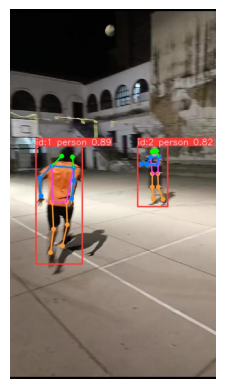

In [20]:
path0= 'C:\\MI-CARRERA\\Semestre7\\SIS330\\PROYECTO\\prueba\\buenos\\94resultados\\94_01_inicio..jpg'
img=plt.imread(path0)
plt.imshow(img)#, cv2.COLOR_BGR2RGB)
plt.axis('off')
plt.show()

In [36]:
b=resultados_carpeta_actual
print(len(b))
df = pd.DataFrame(resultados_carpeta_actual)
print(df)

255
           0         1         2         3    4    5         6         7   \
0    0.739226  0.552291  0.744866  0.549592  0.0  0.0  0.757656  0.554212   
1    0.739463  0.551244  0.745656  0.548745  0.0  0.0  0.760410  0.553872   
2    0.739058  0.549766  0.745164  0.547330  0.0  0.0  0.760277  0.552809   
3    0.738836  0.548704  0.744377  0.545931  0.0  0.0  0.758612  0.550912   
4    0.737824  0.548701  0.743069  0.545642  0.0  0.0  0.757421  0.549793   
..        ...       ...       ...       ...  ...  ...       ...       ...   
250  0.468092  0.537616  0.472793  0.535063  0.0  0.0  0.490075  0.535576   
251  0.465136  0.541990  0.469865  0.539130  0.0  0.0  0.485730  0.539216   
252  0.461190  0.544395  0.466067  0.541939  0.0  0.0  0.481825  0.542509   
253  0.457568  0.546216  0.461761  0.543447  0.0  0.0  0.477541  0.543895   
254  0.451288  0.546466  0.455982  0.543790  0.0  0.0  0.471575  0.545322   

      8    9   ...        24        25        26        27        28  \

In [37]:
df.to_csv("malo3-real"+".txt")

In [43]:
# Visualize the results on the frame
#annotated_frame = results[0].plot()
# Display the annotated frame
#cv2.imshow("detect",annotated_frame)

In [38]:
import os
import cv2
from ultralytics import YOLO

# Load the YOLOv8 model
model = YOLO('yolov8x-pose.pt')
##C:\MI-CARRERA\Semestre 7\SIS330\PROYECTO\Nueva carpeta\imagenes\malos
#C:\MI-CARRERA\Semestre 7\SIS330\PROYECTO\Nueva carpeta\imagenes\buenos
directorio_principal = "C:\\MI-CARRERA\\Semestre7\\SIS330\\imagenes\\malos\\17-malo-4"
guardar= "C:\\MI-CARRERA\\Semestre7\\SIS330\\imagenes\\malos"
resultados_carpeta_actual2=[]
for archivo in os.listdir(directorio_principal):
    
    ruta_archivo = os.path.join(directorio_principal, archivo)
      
    # Leer el fotograma del archivo
    frame = cv2.imread(ruta_archivo)

    # Run YOLOv8 tracking on the frame, persisting tracks between frames
    results = model.track(frame, persist=True)
    # Extrae keypoints de este ID específico
    a= len(results[0].boxes)
    #print(results[0].boxes)
    for i in range(a):
      #print(i)
      if results[0].boxes.id[i] == 4:
        keypoints_de_interes = results[0].keypoints[i].xyn.data.cpu().numpy()
        matriz_np = np.array(keypoints_de_interes)
        matriz_aplanada_np = matriz_np.flatten()
        valor=matriz_aplanada_np.tolist()
        resultados_carpeta_actual2.append(valor)
    # Visualize the results on the frame
    annotated_frame = results[0].plot()
    # Guardar el resultado en la carpeta 'buenos_resultados'
    carpeta_resultados = os.path.join(guardar, "17-resultados")
    os.makedirs(carpeta_resultados, exist_ok=True)
    cv2.imwrite(os.path.join(carpeta_resultados, archivo), annotated_frame)

# Informar que la operación ha finalizado
print("Proceso completado.")
#print(resultados_carpeta_actual)


0: 640x384 6 persons, 779.8ms
Speed: 2.8ms preprocess, 779.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 6 persons, 654.9ms
Speed: 1.6ms preprocess, 654.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 persons, 752.3ms
Speed: 2.0ms preprocess, 752.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 persons, 595.7ms
Speed: 2.0ms preprocess, 595.7ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 persons, 725.2ms
Speed: 1.0ms preprocess, 725.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 persons, 636.4ms
Speed: 2.5ms preprocess, 636.4ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 persons, 758.3ms
Speed: 2.0ms preprocess, 758.3ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 persons, 709.2ms
Speed: 2.1ms preprocess, 709.2ms inference, 1.0ms postprocess per 

In [40]:
df = pd.DataFrame(resultados_carpeta_actual2)
print(df)
df.to_csv("malo4-real"+".txt")

          0         1         2         3         4         5    6    7   \
0   0.116444  0.422495  0.119864  0.419612  0.110596  0.420020  0.0  0.0   
1   0.118178  0.422171  0.120613  0.419275  0.112066  0.419826  0.0  0.0   
2   0.116135  0.421694  0.119463  0.419083  0.110912  0.419058  0.0  0.0   
3   0.116426  0.420437  0.119751  0.417962  0.111509  0.417814  0.0  0.0   
4   0.117399  0.419944  0.120671  0.417482  0.112318  0.417366  0.0  0.0   
5   0.118787  0.420264  0.121867  0.417719  0.113517  0.417666  0.0  0.0   
6   0.118601  0.422081  0.121681  0.419542  0.113188  0.419529  0.0  0.0   
7   0.118964  0.424322  0.121876  0.421815  0.113565  0.421873  0.0  0.0   
8   0.121204  0.427098  0.123232  0.424555  0.115825  0.424834  0.0  0.0   
9   0.122332  0.430426  0.124367  0.427968  0.117076  0.428159  0.0  0.0   
10  0.122853  0.433059  0.125492  0.430700  0.117693  0.430692  0.0  0.0   
11  0.127420  0.434507  0.130327  0.432147  0.122126  0.432067  0.0  0.0   
12  0.130411